# makemore part2
这是karpathy zero  to hero 的第三集

In [326]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [327]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [328]:
len(words)

32033

In [329]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [330]:
block_size = 3

X, Y = [], []
for w in words:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .
charlotte
... ----> c
..c ----> h
.ch ----> a
cha ----> r
har ----> l
arl ----> o
rlo ----> t
lot ----> t
ott ----> e
tte ----> .
mia
... ----> m
..m ----> i
.mi ----> a
mia ----> .
amelia
... ----> a
..a ----> m
.am ----> e
ame ----> l
mel ----> i
eli ----> a
lia ----> .
harper
... ----> h
..h ----> a
.ha ----> r
har ----> p
arp ----> e
rpe ----> r
per ----> .
evelyn
... ----> e
..e ----> v
.ev ----> e
eve ----> l
vel ----> y
ely ----> n
lyn ----> .
abigail
... ----> a
..a ----> b
.ab ----> i
abi ----> g
big ----> a
iga ----> i
gai ----> l
ail ----> .
emily
... ----> e
..e ---

In [331]:
# build the dataset

def build_dataset(words):
    block_size = 3

    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])



torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [332]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [333]:


g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)

w1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
w2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]




In [334]:
sum(p.numel() for p in parameters)
for p in parameters:
    p.requires_grad = True

In [335]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [336]:
lri = []
lossi = []
stepi = []

In [347]:


for i in range(50000):

    ix = torch.randint(0,Xtr.shape[0], (32,))
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(-1, 30) @ w1 + b1) 
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    print(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())


2.273860216140747
2.3893187046051025
2.1401844024658203
1.9959629774093628
2.069173574447632
2.042294979095459
2.1745870113372803
2.2682225704193115
2.3454599380493164
2.059513568878174
2.184666872024536
2.3879361152648926
2.59222674369812
2.1241118907928467
2.1278562545776367
1.9591355323791504
2.398864507675171
2.2293076515197754
2.230051279067993
2.0530905723571777
2.1660356521606445
2.178776264190674
2.457174062728882
2.260127544403076
2.2591683864593506
2.3798727989196777
2.1052491664886475
2.179595470428467
2.3360092639923096
2.3501405715942383
2.1573486328125
1.8296558856964111
2.190361976623535
2.1156206130981445
2.0059242248535156
2.253206253051758
1.9341508150100708
1.8650470972061157
1.7282946109771729
2.304088830947876
1.9667491912841797
2.192100763320923
2.5226292610168457
2.317243814468384
2.1182596683502197
1.9959834814071655
2.5075089931488037
2.1822047233581543
2.1790482997894287
2.087961196899414
1.8321057558059692
2.15565824508667
2.4417881965637207
2.161170721054077

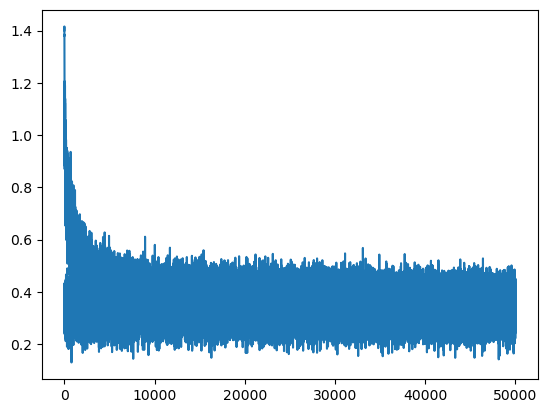

In [348]:
plt.plot(stepi, lossi)



In [349]:
emb = C[Xtr] 
h = torch.tanh(emb.view(-1, 30) @ w1 + b1) 
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.1640191078186035


In [350]:
emb = C[Xdev] 
h = torch.tanh(emb.view(-1, 30) @ w1 + b1) 
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.191037893295288


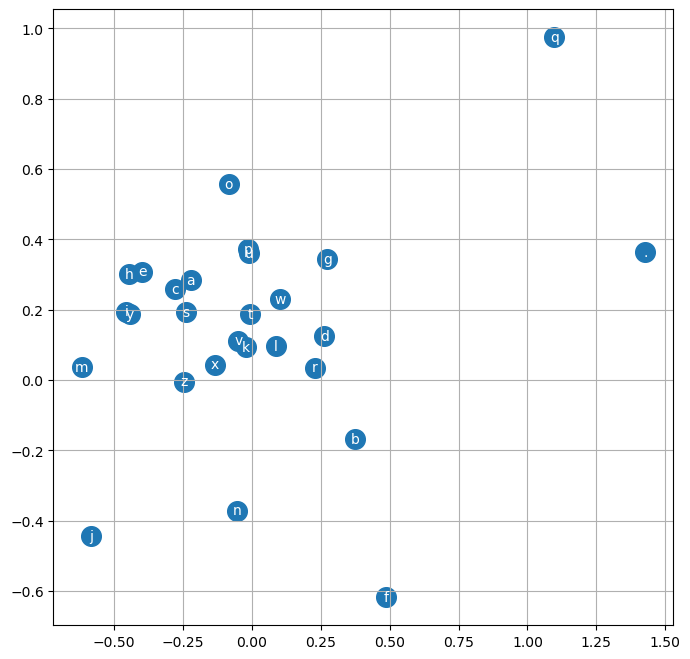

In [351]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(27):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [352]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 30) @ w1 + b1) 
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khi.
mili.
taty.
skandan.
jazhita.
den.
rhciageni.
nellari.
chaiiv.
kaleig.
dham.
evin.
quint.
sulin.
alianni.
wazelon.
jarynix.
kaeliigrached.
